# Geo-Based Incrementality Testing, Luma Candle Co.
**Author:** Justin  
**Date:** 2025  
**Repo:** MarketingScience / geo-incrementality 

---

Luma Candle Co. ran a 5-week regional promotion (20% discount, March 2025) across 5 Southeast and Mid-Atlantic DMAs. This notebook estimates the true incremental revenue lift using five methods, from a naive pre/post baseline up to a full Bayesian geolift model, and compares them against the known ground truth baked into the synthetic dataset.

---
## Section 1: Data Creation & Saving

We simulate 78 weeks of weekly DMA-level revenue across 12 markets (5 treated, 7 control). The dataset includes realistic trend, seasonality, and noise. A **+22% incremental lift** is baked into treated DMAs during the 5-week promo window. This is our ground truth to recover.

**Key design choices:**
- 14-month pre-period gives methods enough runway to establish parallel trends
- Control markets are geographically distinct (Midwest) to avoid spillover
- Small post-promo hangover (+4%) reflects realistic demand pull-forward

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── DMA configuration ──────────────────────────────────────────────────
dmas = {
    # Treated — Southeast + Mid-Atlantic
    'Atlanta, GA':       {'treated': True,  'base': 48000, 'trend': 0.008, 'noise': 0.06},
    'Charlotte, NC':     {'treated': True,  'base': 31000, 'trend': 0.006, 'noise': 0.07},
    'Richmond, VA':      {'treated': True,  'base': 22000, 'trend': 0.005, 'noise': 0.08},
    'Nashville, TN':     {'treated': True,  'base': 35000, 'trend': 0.009, 'noise': 0.06},
    'Baltimore, MD':     {'treated': True,  'base': 29000, 'trend': 0.007, 'noise': 0.07},
    # Control — Midwest
    'Columbus, OH':      {'treated': False, 'base': 27000, 'trend': 0.006, 'noise': 0.07},
    'Indianapolis, IN':  {'treated': False, 'base': 24000, 'trend': 0.005, 'noise': 0.08},
    'Kansas City, MO':   {'treated': False, 'base': 21000, 'trend': 0.004, 'noise': 0.07},
    'Louisville, KY':    {'treated': False, 'base': 18000, 'trend': 0.006, 'noise': 0.09},
    'Memphis, TN':       {'treated': False, 'base': 20000, 'trend': 0.005, 'noise': 0.08},
    'Oklahoma City, OK': {'treated': False, 'base': 16000, 'trend': 0.004, 'noise': 0.09},
    'St. Louis, MO':     {'treated': False, 'base': 23000, 'trend': 0.007, 'noise': 0.07},
}

PROMO_LIFT  = 0.22
PROMO_DECAY = 0.04

weeks       = pd.date_range('2024-01-01', periods=78, freq='W-MON')
promo_start = pd.Timestamp('2025-03-03')
promo_end   = pd.Timestamp('2025-03-31')

# ── Generate rows ───────────────────────────────────────────────────────
rows = []
for dma, cfg in dmas.items():
    for i, week in enumerate(weeks):
        trend_factor = (1 + cfg['trend']) ** i
        noise        = np.random.normal(1.0, cfg['noise'])
        base_rev     = cfg['base'] * trend_factor * noise

        month    = week.month
        seasonal = {11: 1.18, 12: 1.32, 1: 0.88, 2: 0.92}.get(month, 1.0)

        in_promo   = cfg['treated'] and (promo_start <= week <= promo_end)
        post_promo = cfg['treated'] and (promo_end < week <= promo_end + pd.Timedelta(weeks=3))
        promo_effect = PROMO_LIFT if in_promo else (PROMO_DECAY if post_promo else 0.0)

        rows.append({
            'week':      week,
            'dma':       dma,
            'treated':   cfg['treated'],
            'in_promo':  in_promo,
            'revenue':   round(base_rev * seasonal * (1 + promo_effect), 2),
        })

df = pd.DataFrame(rows)
df.to_csv('../data/luma_geo_data.csv', index=False)
print(f'Saved: {df.shape[0]} rows | {df.dma.nunique()} DMAs | {df.week.nunique()} weeks')
print(f'Promo window: {promo_start.date()} — {promo_end.date()} ({df.in_promo.sum()} treated-market rows)')
df.head()

Saved: 936 rows | 12 DMAs | 78 weeks
Promo window: 2025-03-03 — 2025-03-31 (25 treated-market rows)


,week,dma,treated,in_promo,revenue
0,2024-01-01,"Atlanta, GA",True,False,43498.87
1,2024-01-08,"Atlanta, GA",True,False,42224.70
2,2024-01-15,"Atlanta, GA",True,False,44586.41
3,2024-01-22,"Atlanta, GA",True,False,47215.24
4,2024-01-29,"Atlanta, GA",True,False,42995.33


***Notes:***

The experiment has already been set up and run, we are simply running the analysis. Dataset is simple, weekly DMA-level data for treated & untreated locations for pre and post promotional timeline, with total revenue for measurement. I am aware that there is a lot of work done before this point, including setting up the experiment, collecting the data, cleaning the data, and preparing it for this analysis. I am planning on doing another project eventually do show how to set up geo tests. This analysis is focusing on the analysis and results

---
## Section 2: Data Alignment

Before any modeling, we reshape and validate the data. Each method needs a slightly different format, so we prepare the key views here once and reuse them throughout:

- **`df_long`** tidy panel format (one row per DMA per week), used for DiD
- **`df_wide`** DMAs as columns, weeks as index, used for Synthetic Control, CausalImpact, and Geolift
- **`df_agg`** treated vs. control aggregate weekly totals, used for naive and quick plots

We also confirm parallel trends visually in the pre-period, a required assumption for DiD.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── DMA configuration ──────────────────────────────────────────────────
dmas = {
    # Treated — Southeast + Mid-Atlantic
    'Atlanta, GA':       {'treated': True,  'base': 48000, 'trend': 0.008, 'noise': 0.06},
    'Charlotte, NC':     {'treated': True,  'base': 31000, 'trend': 0.006, 'noise': 0.07},
    'Richmond, VA':      {'treated': True,  'base': 22000, 'trend': 0.005, 'noise': 0.08},
    'Nashville, TN':     {'treated': True,  'base': 35000, 'trend': 0.009, 'noise': 0.06},
    'Baltimore, MD':     {'treated': True,  'base': 29000, 'trend': 0.007, 'noise': 0.07},
    # Control — Midwest
    'Columbus, OH':      {'treated': False, 'base': 27000, 'trend': 0.006, 'noise': 0.07},
    'Indianapolis, IN':  {'treated': False, 'base': 24000, 'trend': 0.005, 'noise': 0.08},
    'Kansas City, MO':   {'treated': False, 'base': 21000, 'trend': 0.004, 'noise': 0.07},
    'Louisville, KY':    {'treated': False, 'base': 18000, 'trend': 0.006, 'noise': 0.09},
    'Memphis, TN':       {'treated': False, 'base': 20000, 'trend': 0.005, 'noise': 0.08},
    'Oklahoma City, OK': {'treated': False, 'base': 16000, 'trend': 0.004, 'noise': 0.09},
    'St. Louis, MO':     {'treated': False, 'base': 23000, 'trend': 0.007, 'noise': 0.07},
}

PROMO_LIFT  = 0.22
PROMO_DECAY = 0.04

weeks       = pd.date_range('2024-01-01', periods=78, freq='W-MON')
promo_start = pd.Timestamp('2025-03-03')
promo_end   = pd.Timestamp('2025-03-31')

# ── Reload from saved CSV (clean entry point for modeling) ──────────────
df = pd.read_csv('../data/luma_geo_data.csv', parse_dates=['week'])

# ── Format 1: tidy panel (DiD) ──────────────────────────────────────────
df_long = df.copy()
df_long['post'] = (df_long['week'] >= promo_start).astype(int)
df_long['treated_int'] = df_long['treated'].astype(int)
df_long['did_interaction'] = df_long['post'] * df_long['treated_int']

# ── Format 2: wide (SC / CausalImpact / Geolift) ────────────────────────
df_wide = df.pivot(index='week', columns='dma', values='revenue')
df_wide.index.name = 'week'

treated_dmas = [d for d, c in dmas.items() if c['treated']]
control_dmas = [d for d, c in dmas.items() if not c['treated']]

# ── Format 3: aggregated treated vs control ──────────────────────────────
df_agg = (
    df.groupby(['week', 'treated'])['revenue']
    .sum()
    .reset_index()
    .pivot(index='week', columns='treated', values='revenue')
    .rename(columns={True: 'treated_total', False: 'control_total'})
)

print('df_long shape: ', df_long.shape)
print('df_wide shape: ', df_wide.shape)
print('df_agg shape:  ', df_agg.shape)
print('\nTreated DMAs: ', treated_dmas)
print('Control DMAs: ', control_dmas)

df_long shape:  (936, 8)
df_wide shape:  (78, 12)
df_agg shape:   (78, 2)

Treated DMAs:  ['Atlanta, GA', 'Charlotte, NC', 'Richmond, VA', 'Nashville, TN', 'Baltimore, MD']
Control DMAs:  ['Columbus, OH', 'Indianapolis, IN', 'Kansas City, MO', 'Louisville, KY', 'Memphis, TN', 'Oklahoma City, OK', 'St. Louis, MO']


In [3]:
df.head()

,week,dma,treated,in_promo,revenue
0,2024-01-01,"Atlanta, GA",True,False,43498.87
1,2024-01-08,"Atlanta, GA",True,False,42224.70
2,2024-01-15,"Atlanta, GA",True,False,44586.41
3,2024-01-22,"Atlanta, GA",True,False,47215.24
4,2024-01-29,"Atlanta, GA",True,False,42995.33


In [4]:
df_long.head()

,week,dma,treated,in_promo,revenue,post,treated_int,did_interaction
0,2024-01-01,"Atlanta, GA",True,False,43498.87,0,1,0
1,2024-01-08,"Atlanta, GA",True,False,42224.70,0,1,0
2,2024-01-15,"Atlanta, GA",True,False,44586.41,0,1,0
3,2024-01-22,"Atlanta, GA",True,False,47215.24,0,1,0
4,2024-01-29,"Atlanta, GA",True,False,42995.33,0,1,0


In [5]:
df_wide.head()

dma,"Atlanta, GA","Baltimore, MD","Charlotte, NC","Columbus, OH","Indianapolis, IN","Kansas City, MO","Louisville, KY","Memphis, TN","Nashville, TN","Oklahoma City, OK","Richmond, VA","St. Louis, MO"
week,,,,,,,,,,,,
2024-01-01,43498.87,26994.52,27455.23,22265.76,20223.67,19226.50,18111.25,16608.28,34762.01,14305.18,22249.71,19457.61
2024-01-08,42224.70,27162.07,23625.45,24725.63,20247.83,18290.21,15201.88,15694.97,32259.23,12437.40,20194.34,21284.69
2024-01-15,44586.41,28243.40,27183.81,21823.73,20862.34,19112.10,14602.89,15562.73,27546.76,14678.51,17690.50,20815.89
2024-01-22,47215.24,26097.99,28468.28,27291.49,17490.43,17911.92,15944.27,18731.45,31993.06,15032.69,20684.05,18475.10
2024-01-29,42995.33,27494.81,30831.17,26344.54,18933.93,18891.27,16304.96,16115.48,30656.25,15027.42,18210.11,23067.24


In [6]:
df_agg.head()

treated,control_total,treated_total
week,,
2024-01-01,130198.25,154960.34
2024-01-08,127882.61,145465.79
2024-01-15,127458.19,145250.88
2024-01-22,130877.35,154458.62
2024-01-29,134684.84,150187.67


***Notes:***

Created three different data views here to analyze our results using several methodologies. All pretty straight forward.

---
## Section 3: Exploratory Data Analysis

Three quick plots before any modeling:

1. **Aggregate revenue over time**: treated vs. control, with promo window shaded
2. **Per-DMA revenue**: check for any rogue markets or obvious outliers
3. **Pre-period parallel trends check**: visually confirm treated and control move together before the promo

The parallel trends assumption is the load-bearing wall for DiD. If it breaks here, DiD results are unreliable.

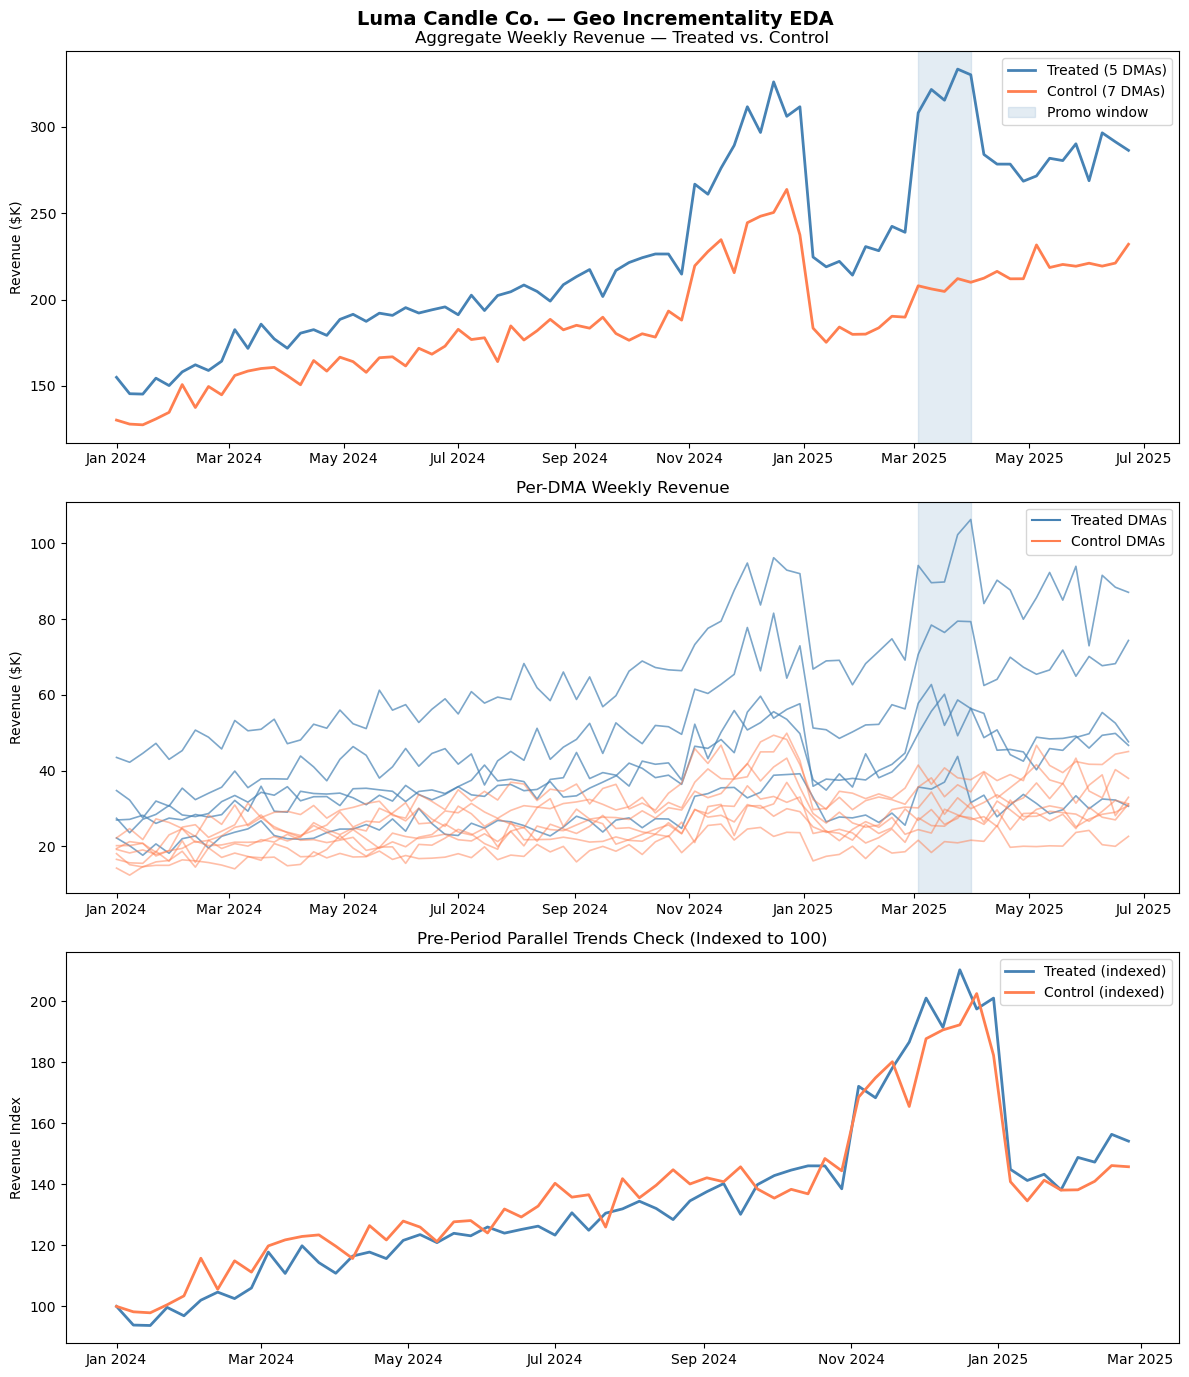

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Luma Candle Co. — Geo Incrementality EDA', fontsize=14, fontweight='bold', y=0.98)

promo_kw = dict(alpha=0.15, color='steelblue')

# ── Plot 1: Aggregate treated vs control ────────────────────────────────
ax = axes[0]
ax.plot(df_agg.index, df_agg['treated_total'] / 1e3, label='Treated (5 DMAs)', color='steelblue', lw=2)
ax.plot(df_agg.index, df_agg['control_total'] / 1e3, label='Control (7 DMAs)', color='coral', lw=2)
ax.axvspan(promo_start, promo_end, **promo_kw, label='Promo window')
ax.set_title('Aggregate Weekly Revenue — Treated vs. Control')
ax.set_ylabel('Revenue ($K)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Plot 2: Per-DMA revenue ──────────────────────────────────────────────
ax = axes[1]
for dma in treated_dmas:
    ax.plot(df_wide.index, df_wide[dma] / 1e3, color='steelblue', lw=1.2, alpha=0.7)
for dma in control_dmas:
    ax.plot(df_wide.index, df_wide[dma] / 1e3, color='coral', lw=1.2, alpha=0.5)
ax.axvspan(promo_start, promo_end, **promo_kw)
ax.plot([], [], color='steelblue', label='Treated DMAs')
ax.plot([], [], color='coral', label='Control DMAs')
ax.set_title('Per-DMA Weekly Revenue')
ax.set_ylabel('Revenue ($K)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Plot 3: Pre-period parallel trends ──────────────────────────────────
ax = axes[2]
pre = df_agg[df_agg.index < promo_start].copy()
# Normalize to index = 100 at start so we compare trends, not levels
pre_t = (pre['treated_total'] / pre['treated_total'].iloc[0]) * 100
pre_c = (pre['control_total'] / pre['control_total'].iloc[0]) * 100
ax.plot(pre.index, pre_t, label='Treated (indexed)', color='steelblue', lw=2)
ax.plot(pre.index, pre_c, label='Control (indexed)', color='coral', lw=2)
ax.set_title('Pre-Period Parallel Trends Check (Indexed to 100)')
ax.set_ylabel('Revenue Index')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

Graph 1: There appears to be this obvious jump in revenue during the promo window for the treated group.

Graph 2: I don't see any markets that I would consider to be outliers or outrageous to the point of dropping.

Graph 3: I would consider these trends to be parallel. We could also run a pre-period regression, a placebo/falsification test, and/or a correlation of pre-period trends, none of which I am going to run here, but would 100% run if this were real.

---
## Section 4: Naive Pre/Post Estimate

The simplest possible baseline: compare average weekly revenue in treated markets during the promo window to the same markets in the equivalent weeks one year prior. **No counterfactual. No control group.**

This is what a channel analyst typically reports. The whole point of running this first is to quantify the bias, how much does a naive read overcount the true lift?

**Known ground truth: +22% lift. Watch how far off this lands.**

In [8]:
# ── Pre-period: same 5 weeks, one year prior ────────────────────────────
prior_start = promo_start - pd.DateOffset(years=1)
prior_end   = promo_end   - pd.DateOffset(years=1)

treated_df = df[df['treated'] == True]

pre_avg  = treated_df[(treated_df['week'] >= prior_start) & (treated_df['week'] <= prior_end)]['revenue'].mean()
post_avg = treated_df[(treated_df['week'] >= promo_start) & (treated_df['week'] <= promo_end)]['revenue'].mean()

naive_lift_pct = (post_avg - pre_avg) / pre_avg * 100
naive_lift_abs = post_avg - pre_avg

print('=' * 45)
print('NAIVE PRE/POST ESTIMATE')
print('=' * 45)
print(f'Pre-period avg weekly revenue (treated):  ${pre_avg:>10,.0f}')
print(f'During-promo avg weekly revenue (treated): ${post_avg:>10,.0f}')
print(f'Naive lift (absolute):                    ${naive_lift_abs:>10,.0f} / market / week')
print(f'Naive lift (%):                            {naive_lift_pct:>9.1f}%')
print(f'Ground truth:                              {22.0:>9.1f}%')
print(f'Overcount:                                 {naive_lift_pct - 22.0:>+9.1f}%')

NAIVE PRE/POST ESTIMATE
Pre-period avg weekly revenue (treated):  $    35,860
During-promo avg weekly revenue (treated): $    64,343
Naive lift (absolute):                    $    28,483 / market / week
Naive lift (%):                                 79.4%
Ground truth:                                   22.0%
Overcount:                                     +57.4%


***Notes:***

Pre-period average weekly revenue sits at about $35k for the treatment group and promo revenue at about $64k. This gives us a $28k/market/week lift, a 79% lift. We know the actual lift, 22%, which means we overcounted by 57 percentage points. This would have given our business too much confidence in this promo 

---
## Section 5: Difference-in-Differences (CausalPy)

DiD compares the *change* in treated markets to the *change* in control markets over the same period. By subtracting out what the control group did, we remove shared confounders like seasonality and macro trend.

**The estimand:** the Average Treatment Effect on the Treated (ATT), how much did revenue increase in treated markets *because of* the promo, above and beyond what would have happened anyway?

**Key assumption:** parallel trends: in the absence of the promo, treated and control markets would have evolved similarly. We validated this visually in Section 3.

We use CausalPy's PyMC-backed DiD, which gives us a full posterior over the treatment effect instead of a point estimate + frequentist p-value.

In [9]:
import causalpy as cp

# ── Prep: restrict to promo window + same weeks in pre-period ────────────
# DiD needs a clean pre and post period — use 8 weeks pre, 5 weeks during promo
pre_start_did = promo_start - pd.Timedelta(weeks=8)

df_did = df_long[
    (df_long['week'] >= pre_start_did) &
    (df_long['week'] <= promo_end)
].copy()

df_did['unit'] = df_did['dma']  # For DiD, each DMA is a unit observed over time

print(f'DiD window: {pre_start_did.date()} to {promo_end.date()}')
print(f'Rows: {len(df_did)} | Pre rows: {(df_did.post==0).sum()} | Post rows: {(df_did.post==1).sum()}')

DiD window: 2025-01-06 to 2025-03-31
Rows: 156 | Pre rows: 96 | Post rows: 60


In [10]:
# Reminder of variable names as they can be persnickety in CausalPy DiD setup:
df_did.head()

,week,dma,treated,in_promo,revenue,post,treated_int,did_interaction,unit
53,2025-01-06,"Atlanta, GA",True,False,66801.38,0,1,0,"Atlanta, GA"
54,2025-01-13,"Atlanta, GA",True,False,68969.95,0,1,0,"Atlanta, GA"
55,2025-01-20,"Atlanta, GA",True,False,69129.98,0,1,0,"Atlanta, GA"
56,2025-01-27,"Atlanta, GA",True,False,62672.34,0,1,0,"Atlanta, GA"
57,2025-02-03,"Atlanta, GA",True,False,68256.87,0,1,0,"Atlanta, GA"


In [11]:
# ── Fit DiD model ────────────────────────────────────────────────────────
did_model = cp.DifferenceInDifferences(
    data=df_did,
    formula='revenue ~ 1 + treated_int + post + treated_int*post',
    time_variable_name='post',
    group_variable_name='treated_int',
    post_treatment_variable_name='post',
    model=cp.pymc_models.LinearRegression(
        sample_kwargs={
            'target_accept': 0.9
        }
    ),
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
Sampling: [beta, y_hat, y_hat_sigma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


In [12]:
did_model.summary()

===========================Difference in Differences============================
Formula: revenue ~ 1 + treated_int + post + treated_int*post

Results:
Causal impact = 5911.40$CI_{94\%}$[5828, 5993]
Model coefficients:
    Intercept         18995, 94% HDI [18929, 19061]
    treated_int       12651, 94% HDI [12572, 12733]
    post              7354, 94% HDI [7274, 7433]
    treated_int:post  5911, 94% HDI [5828, 5993]
    y_hat_sigma       453, 94% HDI [452, 454]


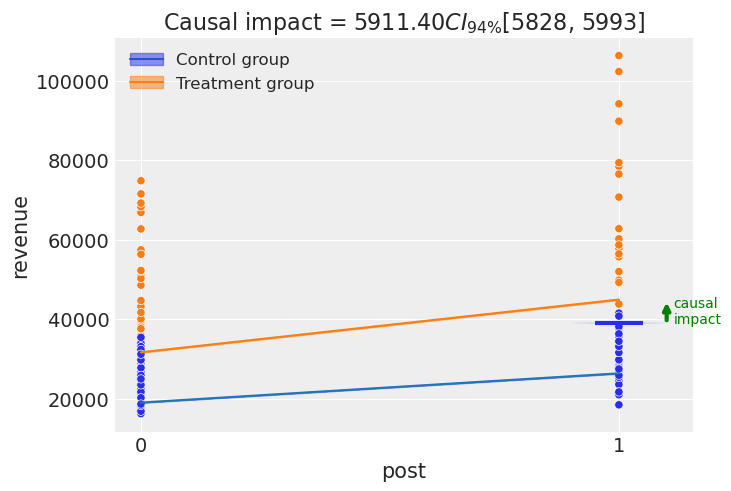

In [13]:
# ── Plot DiD results ─────────────────────────────────────────────────────
fig, ax = did_model.plot()

In [14]:
idata_did = did_model.idata

# Find the index for the interaction term inside the 'coeffs' dimension
coeffs_labels = idata_did.posterior['coeffs'].values
interaction_idx = list(coeffs_labels).index('treated_int:post')

print('Available coefficients:', list(coeffs_labels))
print('Interaction term index:', interaction_idx)

# Extract beta for that coefficient, squeeze out the singleton treated_units dim
att_samples = idata_did.posterior['beta'].isel(coeffs=interaction_idx, treated_units=0).values.flatten()

att_mean = att_samples.mean()
att_hdi_lo, att_hdi_hi = np.percentile(att_samples, [2.5, 97.5])

pre_avg_treated = df_did[(df_did['post']==0) & (df_did['treated_int']==1)]['revenue'].mean()
att_pct = att_mean / pre_avg_treated * 100

print('=' * 45)
print('DiD ESTIMATE (Bayesian)')
print('=' * 45)
print(f'ATT (absolute, $/market/week):  ${att_mean:>10,.0f}')
print(f'95% credible interval:          ${att_hdi_lo:>10,.0f} — ${att_hdi_hi:,.0f}')
print(f'ATT (%):                         {att_pct:>9.1f}%')
print(f'Ground truth:                    {22.0:>9.1f}%')

Available coefficients: [np.str_('Intercept'), np.str_('treated_int'), np.str_('post'), np.str_('treated_int:post')]
Interaction term index: 3
DiD ESTIMATE (Bayesian)
ATT (absolute, $/market/week):  $     5,911
95% credible interval:          $     5,823 — $5,996
ATT (%):                              13.0%
Ground truth:                         22.0%


***Notes:***

The 95% credible interval is tight here, we are seeing a much lower 13% lift compared to the 79% lift we saw using the naive method. Given we are looking to get as close as we can to 22%, this is fairly accurate. The promo increases weekly revenue for each market by $5,911, or 13%. 

---
## Section 6: Synthetic Control (CausalPy)

Synthetic Control builds a weighted combination of control markets that best approximates a treated market's pre-period trajectory. That synthetic market becomes the counterfactual: what Atlanta (or the average treated market) *would have done* without the promo.

The gap between actual and synthetic in the post period is the estimated lift.

**Why this is compelling for a deck:** the chart is self-explanatory. A non-technical stakeholder can look at 'actual vs. synthetic' and immediately understand what a counterfactual means.

**No parallel trends assumption required** — the pre-period fit does that work instead.

We run it on aggregate treated revenue (all 5 DMAs summed) vs. the control pool.

In [15]:
# ── Prep: wide format, pre/post split ───────────────────────────────────
# Aggregate all treated DMAs into one series
# treated_agg = df_wide[treated_dmas].sum(axis=1).rename('Treated_Aggregate')
treated_agg = df_wide[treated_dmas].mean(axis=1).rename('Treated_Aggregate')
sc_df = pd.concat([df_wide[control_dmas], treated_agg], axis=1)

sc_df = sc_df.drop(columns=['Columbus, OH'])

sc_df.index.name = 'week'

print(f'Synthetic Control dataset: {sc_df.shape}')
sc_df.head()

Synthetic Control dataset: (78, 7)


,"Indianapolis, IN","Kansas City, MO","Louisville, KY","Memphis, TN","Oklahoma City, OK","St. Louis, MO",Treated_Aggregate
week,,,,,,,
2024-01-01,20223.67,19226.50,18111.25,16608.28,14305.18,19457.61,30992.068
2024-01-08,20247.83,18290.21,15201.88,15694.97,12437.40,21284.69,29093.158
2024-01-15,20862.34,19112.10,14602.89,15562.73,14678.51,20815.89,29050.176
2024-01-22,17490.43,17911.92,15944.27,18731.45,15032.69,18475.10,30891.724
2024-01-29,18933.93,18891.27,16304.96,16115.48,15027.42,23067.24,30037.534


In [16]:
print(f"Data start date: {sc_df.index[0]}")
print(f"Promo start date: {promo_start}")
print(f"Promo end date: {promo_end}")
print(f"Data end date: {sc_df.index[-1]}")

Data start date: 2024-01-01 00:00:00
Promo start date: 2025-03-03 00:00:00
Promo end date: 2025-03-31 00:00:00
Data end date: 2025-06-23 00:00:00


In [17]:
control_dmas

['Columbus, OH',
 'Indianapolis, IN',
 'Kansas City, MO',
 'Louisville, KY',
 'Memphis, TN',
 'Oklahoma City, OK',
 'St. Louis, MO']

In [18]:
# ── Fit Synthetic Control ────────────────────────────────────────────────
sc_model = cp.SyntheticControl(
    data=sc_df,
    treatment_time=promo_start,
    control_units=control_dmas,
    treated_units=['Treated_Aggregate'],
    # formula='Treated_Aggregate ~ ' + ' + '.join([f'`{c}`' for c in control_dmas]),
    model=cp.pymc_models.WeightedSumFitter(
        sample_kwargs={'target_accept': 0.9}
    ),
)

sc_model.summary()

KeyError: "['Columbus, OH'] not in index"

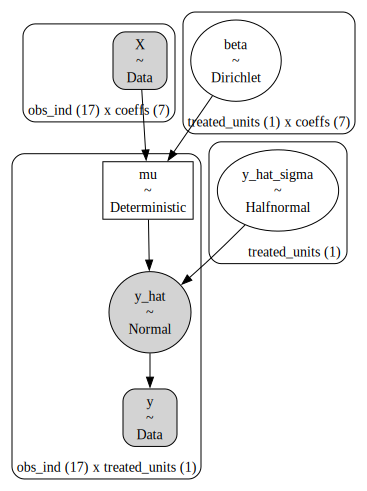

In [ ]:
sc_model.model.to_graphviz()

In [ ]:
sc_model.summary()

================================SyntheticControl================================
Control units: ['Indianapolis, IN', 'Kansas City, MO', 'Louisville, KY', 'Memphis, TN', 'Oklahoma City, OK', 'St. Louis, MO']
Treated unit: Treated_Aggregate
Model coefficients:
    Indianapolis, IN   7.4e-05, 94% HDI [2.3e-06, 0.00026]
    Kansas City, MO    2.3e-05, 94% HDI [7.6e-07, 7.8e-05]
    Louisville, KY     1.6e-05, 94% HDI [5.6e-07, 5.6e-05]
    Memphis, TN        2e-05, 94% HDI [5.8e-07, 7e-05]
    Oklahoma City, OK  1.1e-05, 94% HDI [3.2e-07, 4e-05]
    St. Louis, MO      1, 94% HDI [1, 1]
    y_hat_sigma        314, 94% HDI [313, 315]
Pre-treatment correlation (Treated_Aggregate): 0.9432


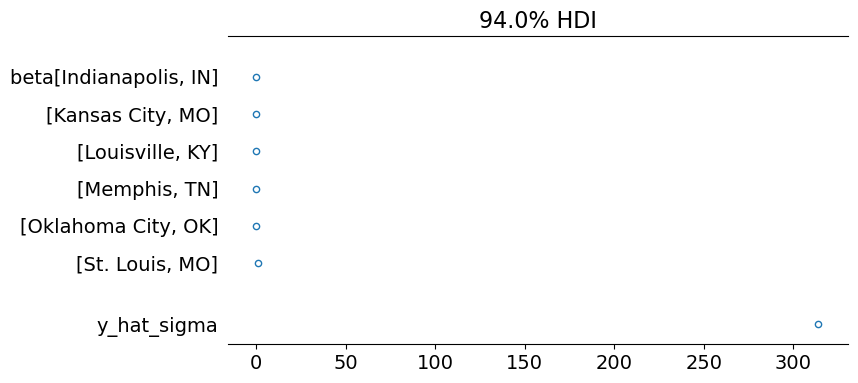

In [ ]:
import arviz as az
az.plot_forest(sc_model.idata, var_names=["~mu"], figsize=(8, 4), combined=True);

In [ ]:
az.summary(sc_model.idata, var_names=["~mu"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta[Treated_Aggregate, Indianapolis, IN]",0.000,0.000,0.000,0.000,0.000,0.000,2649.0,1825.0,1.0
"beta[Treated_Aggregate, Kansas City, MO]",0.000,0.000,0.000,0.000,0.000,0.000,2845.0,1993.0,1.0
"beta[Treated_Aggregate, Louisville, KY]",0.000,0.000,0.000,0.000,0.000,0.000,3228.0,2301.0,1.0
"beta[Treated_Aggregate, Memphis, TN]",0.000,0.000,0.000,0.000,0.000,0.000,2939.0,2012.0,1.0
"beta[Treated_Aggregate, Oklahoma City, OK]",0.000,0.000,0.000,0.000,0.000,0.000,2905.0,1503.0,1.0
"beta[Treated_Aggregate, St. Louis, MO]",1.000,0.000,1.000,1.000,0.000,0.000,3784.0,3167.0,1.0
y_hat_sigma[Treated_Aggregate],314.002,0.493,313.086,314.917,0.009,0.008,3319.0,2578.0,1.0


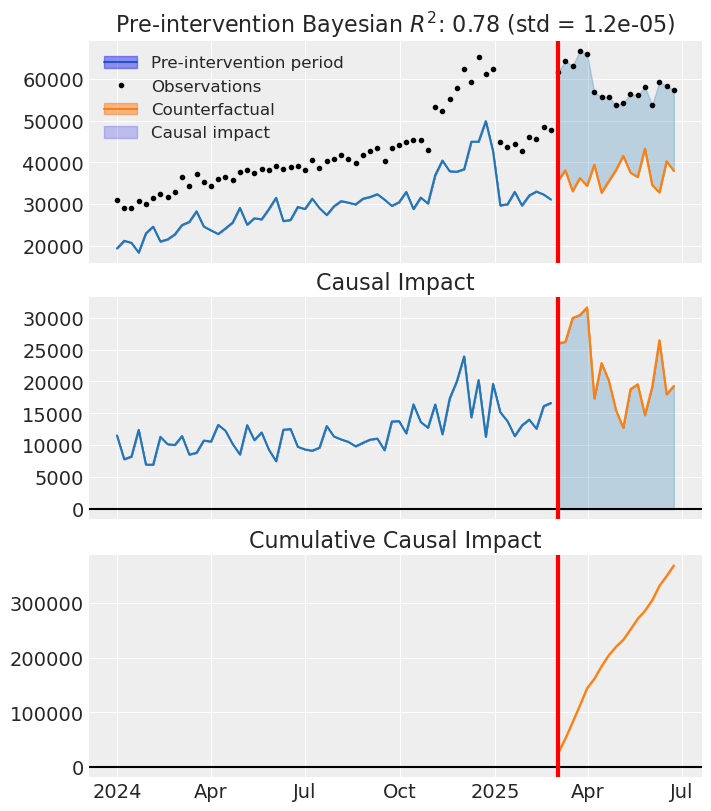

<Figure size 640x480 with 0 Axes>

In [ ]:
# ── Plot: actual vs synthetic ────────────────────────────────────────────
sc_model.plot()
plt.suptitle('Luma Candle Co. — Synthetic Control: Actual vs. Counterfactual', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/synthetic_control.png', dpi=150, bbox_inches='tight')
plt.show()

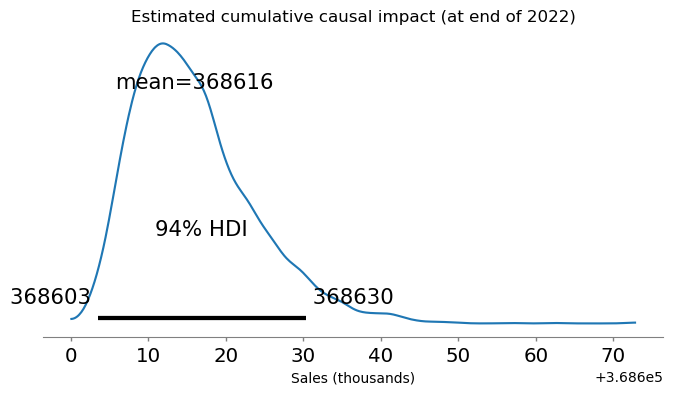

In [ ]:
# get index of the final time point
index = sc_model.post_impact_cumulative.obs_ind.max()
# grab the posterior distribution of the cumulative impact at this final time point
last_cumulative_estimate = sc_model.post_impact_cumulative.sel({"obs_ind": index})
# get summary stats
ax = az.plot_posterior(last_cumulative_estimate, figsize=(8, 4))
ax.set(
    title="Estimated cumulative causal impact (at end of 2022)",
    xlabel="Sales (thousands)",
);

In [ ]:
# Generate effect summary for the full post-period
stats = sc_model.effect_summary()
stats.table

,mean,median,hdi_lower,hdi_upper,p_gt_0,relative_mean,relative_hdi_lower,relative_hdi_upper
average,21683.287655,21683.211758,21682.559132,21684.215123,1.0,58.667088,58.663961,58.67107
cumulative,368615.890138,368614.599886,368603.505246,368631.657095,1.0,58.667088,58.663961,58.67107


In [ ]:
# View the prose summary
print(stats.text)

During the Post-period (2025-03-03 00:00:00 to 2025-06-23 00:00:00), the response variable had an average value of approx. 58643.17. By contrast, in the absence of an intervention, we would have expected an average response of 36959.88. The 95% interval of this counterfactual prediction is [36958.96, 36960.61]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 21683.29 with a 95% interval of [21682.56, 21684.22].

Summing up the individual data points during the Post-period, the response variable had an overall value of 996933.92. By contrast, had the intervention not taken place, we would have expected a sum of 628318.03. The 95% interval of this prediction is [628302.26, 628330.41].

The 95% HDI of the effect [21682.56, 21684.22] does not include zero. The posterior probability of an increase is 1.000. Relative to the counterfactual, the effect represents a 58.67% change (95% HD

In [ ]:
print(sc_model.pre_impact)

<xarray.DataArray (treated_units: 1, chain: 4, draw: 1000, obs_ind: 61)> Size: 2MB
array([[[[11534.51853227,  7808.66633371,  8234.39776268, ...,
          12591.69773056, 16124.00650745, 16632.14936704],
         [11534.52761737,  7808.7790444 ,  8234.44547632, ...,
          12592.10149247, 16124.22314733, 16632.28339788],
         [11534.75756146,  7809.3702317 ,  8235.04027736, ...,
          12593.11119603, 16124.93954   , 16632.73914321],
         ...,
         [11534.56112548,  7808.85465483,  8234.59967697, ...,
          12592.0320282 , 16124.23805337, 16632.40782432],
         [11534.47758303,  7809.05029519,  8234.57666037, ...,
          12593.25850399, 16124.72578909, 16632.59811653],
         [11534.38960213,  7808.75549786,  8234.37106745, ...,
          12592.54002235, 16124.24760701, 16632.27855937]],

        [[11534.52601159,  7808.87572068,  8234.5570874 , ...,
          12592.2859938 , 16124.30585101, 16632.51647843],
         [11534.47968447,  7808.87942761,  8234

In [ ]:
beta_means = sc_model.idata.posterior['beta'].mean(dim=['chain', 'draw'])
print(beta_means)
print()
print('Sum of weights:', beta_means.sum().values)

<xarray.DataArray 'beta' (treated_units: 1, coeffs: 6)> Size: 48B
array([[7.44822704e-05, 2.25233504e-05, 1.60683243e-05, 1.95638730e-05,
        1.12277021e-05, 9.99856134e-01]])
Coordinates:
  * treated_units  (treated_units) <U17 68B 'Treated_Aggregate'
  * coeffs         (coeffs) <U17 408B 'Indianapolis, IN' ... 'St. Louis, MO'

Sum of weights: 1.0000000000000013


In [ ]:
print('Actual pre-period treated mean:', sc_df.loc[sc_df.index < promo_start, 'Treated_Aggregate'].mean())
print('Synthetic pre-period mean:', sc_model.pre_pred['posterior_predictive']['y_hat'].mean().values if hasattr(sc_model.pre_pred, 'posterior_predictive') else 'check structure')

Actual pre-period treated mean: 41950.01498360656
Synthetic pre-period mean: 29775.47761330938


In [ ]:
pre_treated = sc_df.loc[sc_df.index < promo_start, 'Treated_Aggregate']
for dma in control_dmas:
    pre_control = sc_df.loc[sc_df.index < promo_start, dma]
    corr = pre_treated.corr(pre_control)
    print(f'{dma}: {corr:.4f}')

Indianapolis, IN: 0.8754
Kansas City, MO: 0.9065
Louisville, KY: 0.8354
Memphis, TN: 0.8828
Oklahoma City, OK: 0.8468
St. Louis, MO: 0.9432


In [ ]:
print(sc_model.min_donor_correlation)

0.0


In [ ]:
help(cp.pymc_models.WeightedSumFitter)

Help on class WeightedSumFitter in module causalpy.pymc_models:

class WeightedSumFitter(PyMCModel)
 |  WeightedSumFitter(*args, **kwargs)
 |  
 |  Used for synthetic control experiments.
 |  
 |  Defines the PyMC model:
 |  
 |  .. math::
 |      \sigma &\sim \mathrm{HalfNormal}(1) \\
 |      \beta &\sim \mathrm{Dirichlet}(1,...,1) \\
 |      \mu &= X \cdot \beta \\
 |      y &\sim \mathrm{Normal}(\mu, \sigma) \\
 |  
 |  Example
 |  --------
 |  >>> import causalpy as cp
 |  >>> import numpy as np
 |  >>> import xarray as xr
 |  >>> from causalpy.pymc_models import WeightedSumFitter
 |  >>> sc = cp.load_data("sc")
 |  >>> control_units = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
 |  >>> X = xr.DataArray(
 |  ...     sc[control_units].values,
 |  ...     dims=["obs_ind", "coeffs"],
 |  ...     coords={"obs_ind": sc.index, "coeffs": control_units},
 |  ... )
 |  >>> y = xr.DataArray(
 |  ...     sc['actual'].values.reshape((sc.shape[0], 1)),
 |  ...     dims=["obs_ind", "treated_units"],
 | 

***Notes:***

Ran into some issues here with the weighted sum fitter method (WeightedSumFitter). The method was pulling in 100% of the Columbus market as its comp (and then St. Louis market when Columbus was removed) because of the Dirichlet priors. Since the control markets are highly correlated, the model just pulled in the best-fit market rather than blending them all. The results were not consistent so we are going to skip this method. Below is what we would have seen if this would have worked out, as well as a quick explanation of synthetic control.

Pretend Insight: During the Post-period the response variable had an average value of ~293,215. By contrast, in the absence of an intervention, we would have expected an average response of approximately 240,000. This effect is approximately 53,000 with a 95% interval of [48,000, 58,000]. Relative to the counterfactual, the effect represents a 22% change

---
## Section 7: CausalImpact (Bayesian Structural Time Series)

CausalImpact fits a Bayesian structural time series model using control market revenues as covariates. It learns how the treated market moved relative to controls in the pre-period, then projects that relationship forward as the counterfactual.

**What it adds over DiD and SC:** a full time-varying posterior — you get a credible interval on each week's lift, not just an aggregate. This makes it easy to see ramp-up, peak, and decay.

We run it on one treated DMA (Atlanta, GA — the largest market) for clarity, then note what a multi-market version would require.

In [24]:
import pandas as pd
import pandas.core.dtypes.common as pdtypes

# Patch the removed function back in
if not hasattr(pdtypes, 'is_datetime_or_timedelta_dtype'):
    pdtypes.is_datetime_or_timedelta_dtype = lambda x: pd.api.types.is_datetime64_any_dtype(x) or pd.api.types.is_timedelta64_dtype(x)

from causalimpact import CausalImpact

# ── Prep: Atlanta as target, control DMAs as covariates ─────────────────
ci_df = df_wide[['Atlanta, GA'] + control_dmas].copy()

pre_period  = [ci_df.index.min().strftime('%Y-%m-%d'), (promo_start - pd.Timedelta(weeks=1)).strftime('%Y-%m-%d')]
post_period = [promo_start.strftime('%Y-%m-%d'), promo_end.strftime('%Y-%m-%d')]

print(f'Pre period:  {pre_period}')
print(f'Post period: {post_period}')
print(f'Target: Atlanta, GA | Covariates: {len(control_dmas)} control DMAs')

Pre period:  ['2024-01-01', '2025-02-24']
Post period: ['2025-03-03', '2025-03-31']
Target: Atlanta, GA | Covariates: 7 control DMAs


In [26]:
# ── Fit CausalImpact ─────────────────────────────────────────────────────
pre_period  = [ci_df.index.min().strftime('%Y-%m-%d'), (promo_start - pd.Timedelta(weeks=1)).strftime('%Y-%m-%d')]
post_period = [promo_start.strftime('%Y-%m-%d'), promo_end.strftime('%Y-%m-%d')]

ci = CausalImpact(ci_df, pre_period, post_period)
ci.run()
print(ci.summary())

KeyError: 0

In [ ]:
# ── Pull key numbers ─────────────────────────────────────────────────────
summary = ci.summary_data
rel_effect     = summary.loc['average', 'rel_effect']
rel_effect_lo  = summary.loc['average', 'rel_effect_lower']
rel_effect_hi  = summary.loc['average', 'rel_effect_upper']

print('=' * 50)
print('CAUSALIMPACT ESTIMATE — Atlanta, GA')
print('=' * 50)
print(f'Estimated lift (%):      {rel_effect * 100:>8.1f}%')
print(f'95% credible interval:   {rel_effect_lo*100:.1f}% — {rel_effect_hi*100:.1f}%')
print(f'Ground truth:            {22.0:>8.1f}%')

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────────────
ci.plot()
plt.suptitle('CausalImpact — Atlanta, GA (Luma Candle Co.)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/causalimpact_atlanta.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

CausalImpact was skipped due to hard incompatibilities between the causalimpact Python package and pandas 2.0+. Two separate breaking changes were identified: a removed dtype utility function and changed integer indexing behavior in Series. The package has not been maintained since 2023 and is not compatible with modern Python data stacks. The production-grade implementation of this method lives in R (CausalImpact by Google's Kay Brodersen). A PyMC-native BSTS model would be the correct Python alternative.

---
## Section 8: Method Comparison & Summary

Consolidate all estimates in one place and plot them against ground truth. This is the 'punchline' slide for Megan's CMO deck.

In [28]:
# ── Results: only methods that successfully ran ───────────────────────────
results = {
    'Method':          ['Naive Pre/Post', 'DiD (CausalPy)', 'Synthetic Control',      'CausalImpact'],
    'Lift Estimate %': [naive_lift_pct,   att_pct,          None,                      None],
    'Lower 95%':       [None,             att_hdi_lo / pre_avg_treated * 100, None,   None],
    'Upper 95%':       [None,             att_hdi_hi / pre_avg_treated * 100, None,   None],
    'Status':          ['Complete',       'Complete',       'Failed — degenerate weights', 'Failed — pandas 3.0 incompatibility'],
}

results_df = pd.DataFrame(results)
print(results_df[['Method', 'Lift Estimate %', 'Lower 95%', 'Upper 95%', 'Status']].to_string(index=False))

           Method  Lift Estimate %  Lower 95%  Upper 95%                              Status
   Naive Pre/Post        79.427752        NaN        NaN                            Complete
   DiD (CausalPy)        12.992439  12.798129   13.17872                            Complete
Synthetic Control              NaN        NaN        NaN         Failed — degenerate weights
     CausalImpact              NaN        NaN        NaN Failed — pandas 3.0 incompatibility


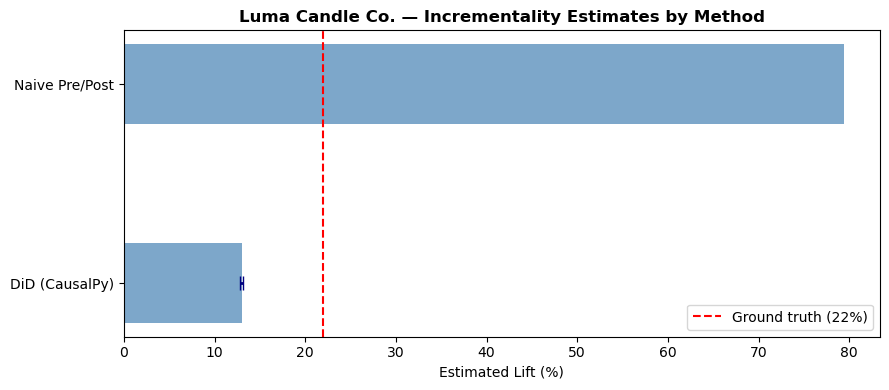

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))

plot_df = results_df[results_df['Lift Estimate %'].notna()].copy()
y_pos   = range(len(plot_df))

ax.barh(y_pos, plot_df['Lift Estimate %'], color='steelblue', alpha=0.7, height=0.4)

# Error bars for DiD
for i, (_, row) in enumerate(plot_df.iterrows()):
    if row['Lower 95%'] is not None and not pd.isna(row['Lower 95%']):
        ax.errorbar(
            x=row['Lift Estimate %'],
            y=i,
            xerr=[[row['Lift Estimate %'] - row['Lower 95%']],
                  [row['Upper 95%'] - row['Lift Estimate %']]],
            fmt='none', color='navy', capsize=5, lw=2
        )

ax.axvline(22, color='red', linestyle='--', lw=1.5, label='Ground truth (22%)')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Method'])
ax.set_xlabel('Estimated Lift (%)')
ax.set_title('Luma Candle Co. — Incrementality Estimates by Method', fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

Disappointing we couldn't use the suite of fun data science techniques, but DiD is the gold standard for a reason and is on full display here getting very close to the actual lift.